# 05 — Model Comparison
### Unified comparison table for thesis — RMSE, MAE, Accuracy, F1
> Run all four model notebooks first.

In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Load all results
results = []
for fname, label in [
    ('lstm_results.pkl',     'LSTM (Baseline 1)'),
    ('gru_results.pkl',      'GRU (Baseline 2)'),
    ('cnn_lstm_results.pkl', 'CNN-LSTM (Baseline 3)'),
    ('fag_tft_results.pkl',  'FAG-TFT (Proposed)'),
]:
    with open(fname,'rb') as f: r = pickle.load(f)
    r['model'] = label
    results.append(r)

df = pd.DataFrame(results)[['model','accuracy','f1','rmse','mae']]
df['accuracy_pct'] = (df['accuracy'] * 100).round(2)
df['f1']   = df['f1'].round(4)
df['rmse'] = df['rmse'].round(4)
df['mae']  = df['mae'].round(4)

display_df = df[['model','accuracy_pct','f1','rmse','mae']].copy()
display_df.columns = ['Model', 'Accuracy (%)', 'F1 Score', 'RMSE', 'MAE']
print('='*70)
print('MODEL COMPARISON RESULTS')
print('='*70)
print(display_df.to_string(index=False))
print()
best_idx = df['accuracy'].idxmax()
print(f'Best Model: {display_df.iloc[best_idx]["Model"]} '
      f'(Accuracy: {display_df.iloc[best_idx]["Accuracy (%)"]:.2f}%)')

MODEL COMPARISON RESULTS
                Model  Accuracy (%)  F1 Score   RMSE    MAE
    LSTM (Baseline 1)         77.06    0.8067 0.9515 0.4073
     GRU (Baseline 2)         62.92    0.7201 1.4218 0.7912
CNN-LSTM (Baseline 3)         92.04    0.8823 0.5439 0.1386
   FAG-TFT (Proposed)         91.85    0.8813 0.5457 0.1404

Best Model: CNN-LSTM (Baseline 3) (Accuracy: 92.04%)


#### Comparison Charts

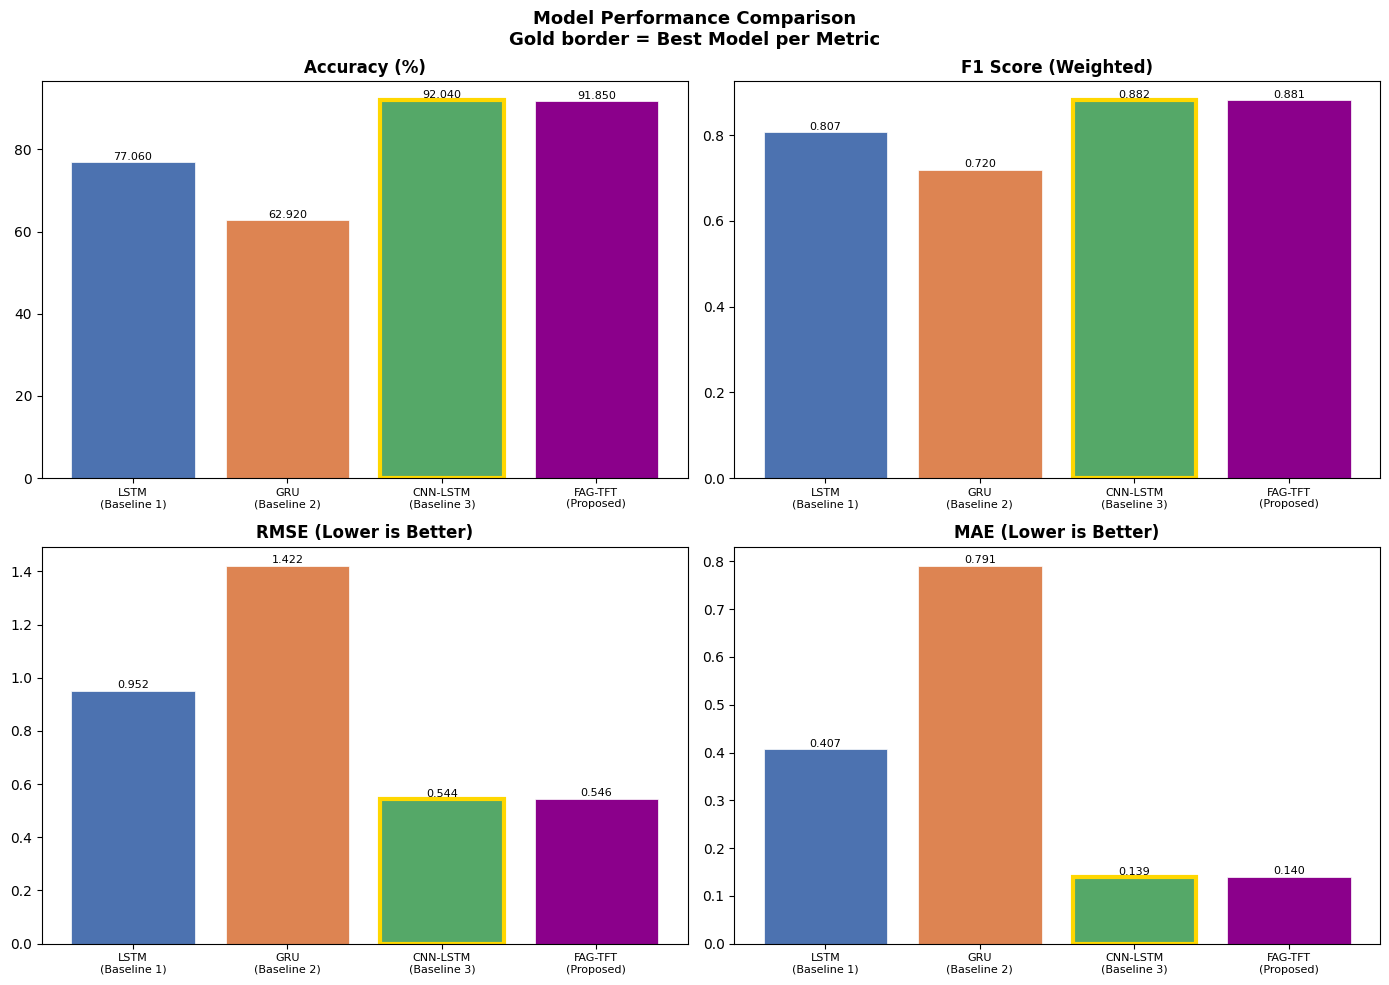

✅ Comparison chart saved — use this in your thesis.


In [2]:
models  = display_df['Model'].tolist()
colors  = ['#4C72B0','#DD8452','#55A868','#8B008B']
x       = np.arange(len(models))

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
metrics = [
    ('Accuracy (%)', 'Accuracy (%)', True),
    ('F1 Score',     'F1 Score (Weighted)', True),
    ('RMSE',         'RMSE (Lower is Better)', False),
    ('MAE',          'MAE (Lower is Better)', False),
]

for ax, (col, title, higher_better) in zip(axes.flat, metrics):
    vals = display_df[col].values
    bars = ax.bar(x, vals, color=colors, edgecolor='white', linewidth=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels([m.replace(' (',  '\n(') for m in models], fontsize=8)
    ax.set_title(title, fontweight='bold')
    # Highlight best
    best = np.argmax(vals) if higher_better else np.argmin(vals)
    bars[best].set_edgecolor('gold')
    bars[best].set_linewidth(3)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Model Performance Comparison\nGold border = Best Model per Metric',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Comparison chart saved — use this in your thesis.')

In [3]:
# Save comparison table as CSV for thesis
display_df.to_csv('model_comparison_results.csv', index=False)
print('✅ Results saved to model_comparison_results.csv')

✅ Results saved to model_comparison_results.csv
